# Ejercicio 4 - Analisis exploratorio con DuckDB

Este cuaderno analiza los viajes Yellow y Green Taxi disponibles para 2026. Las consultas se ejecutan directamente con DuckDB sobre los archivos Parquet procesados por el ejercicio 3; solo los resultados agregados se convierten a pandas para mostrarlos y visualizarlos.

Antes de ejecutarlo:

1. Ejecute `scripts/download_data.py`.
2. Ejecute completamente `notebooks/ejercicio_3.ipynb`.
3. Compruebe que existen `data/processed/yellow_2026.parquet` y `data/processed/green_2026.parquet`.

## 4.1 Preguntas de analisis

1. ¿Como evoluciona mensualmente el volumen de viajes y el monto generado por cada tipo de taxi?
2. ¿En que horas del dia se concentra la demanda de Yellow y Green Taxi?
3. ¿Que diferencias existen en distancia, duracion, pasajeros y monto entre ambos tipos?
4. ¿Cuales son los medios de pago mas utilizados?
5. ¿Como se comportan las propinas en viajes pagados con tarjeta?
6. ¿Como se distribuyen las distancias de los viajes?
7. ¿Que posibles valores atipicos o inconsistencias permanecen despues de la limpieza?
8. ¿Que zonas de recogida concentran mas viajes?

Estas preguntas cubren comportamiento temporal, caracteristicas de los viajes, diferencias entre servicios, pagos, distribuciones y calidad de datos.

In [1]:
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
NOTEBOOKS = ROOT / 'notebooks'
os.chdir(NOTEBOOKS)

processed = ROOT / 'data' / 'processed'
required = [processed / 'yellow_2026.parquet', processed / 'green_2026.parquet']
missing = [str(path.relative_to(ROOT)) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Faltan archivos procesados: ' + ', '.join(missing)
        + '. Ejecute primero download_data.py y ejercicio_3.ipynb.'
    )

con = duckdb.connect()

def run_sql(number):
    path = ROOT / 'sql' / f'ejercicio_4_{number}.sql'
    return con.execute(path.read_text(encoding='utf-8')).df()

print('Archivos procesados encontrados. Ambiente listo.')

Archivos procesados encontrados. Ambiente listo.


## 4.2 Consultas, resultados e interpretacion

Cada apartado referencia la consulta versionada en `sql/`. La fuente de todas las consultas son los dos Parquet procesados de 2026.

### 1. Evolucion mensual

**Consulta:** `sql/ejercicio_4_1.sql`  
**Objetivo:** comparar volumen, monto promedio e ingreso total por mes y tipo de taxi.  
**Decision:** interpretar solamente los meses presentes; un mes parcial no debe compararse como si estuviera completo.

,month,taxi_type,trips,avg_total_amount,total_revenue
0,2026-01-01,green,40138,24.30,9.753845e+05
1,2026-01-01,yellow,3684910,29.82,1.099003e+08
2,2026-02-01,green,37278,24.36,9.080407e+05
3,2026-02-01,yellow,3372574,30.60,1.031852e+08
4,2026-03-01,green,44090,25.01,1.102610e+06
5,2026-03-01,yellow,3931136,30.41,1.195566e+08
6,2026-04-01,green,44088,25.54,1.126174e+06
7,2026-04-01,yellow,3816380,30.23,1.153594e+08
8,2026-05-01,green,44802,26.05,1.166887e+06
9,2026-05-01,yellow,4075947,30.70,1.251273e+08


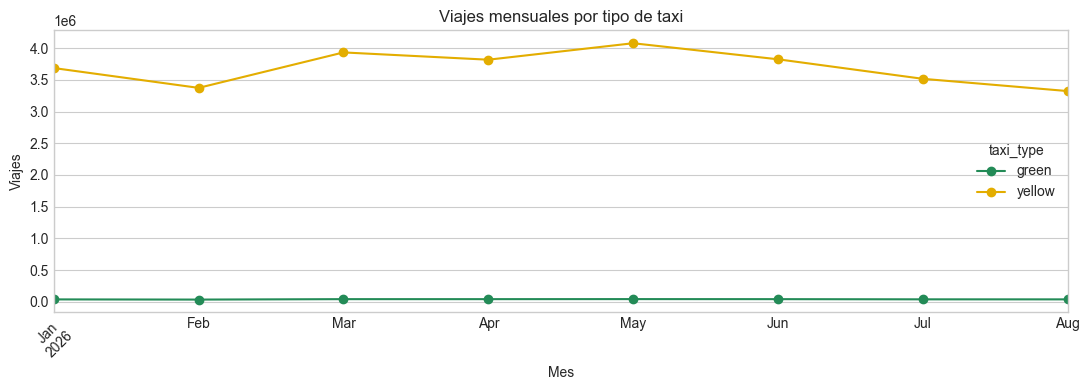

Green: el mayor volumen observado fue 44,802 viajes en 2026-05-01 00:00:00.
Yellow: el mayor volumen observado fue 4,075,947 viajes en 2026-05-01 00:00:00.


In [2]:
monthly = run_sql(1)
display(monthly)

monthly_plot = monthly.pivot(index='month', columns='taxi_type', values='trips')
ax = monthly_plot.plot(figsize=(11, 4), marker='o', color={'yellow': '#e3ad00', 'green': '#238b57'})
ax.set(title='Viajes mensuales por tipo de taxi', xlabel='Mes', ylabel='Viajes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for taxi, group in monthly.groupby('taxi_type'):
    peak = group.loc[group['trips'].idxmax()]
    print(f'{taxi.title()}: el mayor volumen observado fue {peak.trips:,.0f} viajes en {peak.month}.')

### 2. Demanda por hora

**Consulta:** `sql/ejercicio_4_2.sql`  
**Objetivo:** identificar horas pico y comparar el patron intradiario de ambos servicios.  
**Decision:** usar porcentajes dentro de cada tipo para que la diferencia de escala no oculte el patron de Green Taxi.

,taxi_type,pickup_hour,trips,pct_trips
0,green,0,5261,1.57
1,green,1,3349,1.00
2,green,2,2438,0.73
3,green,3,2025,0.60
4,green,4,2052,0.61
5,green,5,2649,0.79
6,green,6,6802,2.02
7,green,7,14198,4.22
8,green,8,17882,5.32
9,green,9,18779,5.59


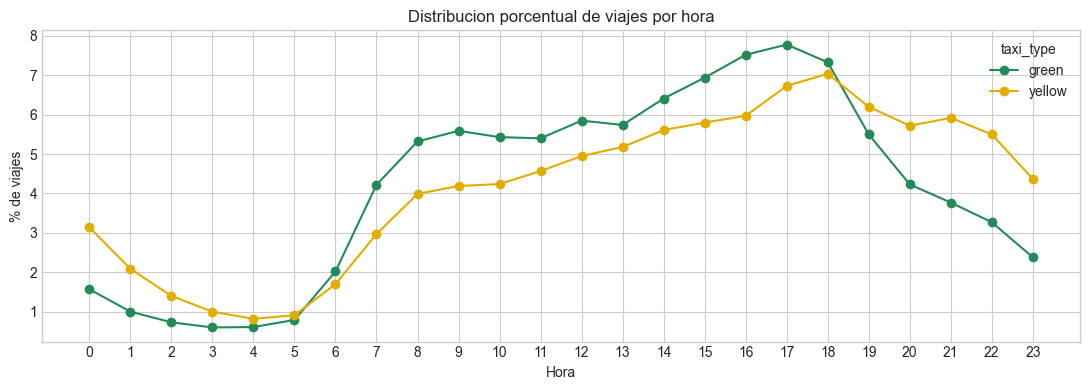

Green: hora pico 17:00, con 7.78% de sus viajes.
Yellow: hora pico 18:00, con 7.04% de sus viajes.


In [3]:
hourly = run_sql(2)
display(hourly)

hourly_plot = hourly.pivot(index='pickup_hour', columns='taxi_type', values='pct_trips')
ax = hourly_plot.plot(figsize=(11, 4), marker='o', color={'yellow': '#e3ad00', 'green': '#238b57'})
ax.set(title='Distribucion porcentual de viajes por hora', xlabel='Hora', ylabel='% de viajes')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

for taxi, group in hourly.groupby('taxi_type'):
    peak = group.loc[group['trips'].idxmax()]
    print(f'{taxi.title()}: hora pico {int(peak.pickup_hour):02d}:00, con {peak.pct_trips:.2f}% de sus viajes.')

### 3. Caracteristicas y diferencias entre Yellow y Green

**Consulta:** `sql/ejercicio_4_3.sql`  
**Objetivo:** comparar distancia, duracion, pasajeros y monto con promedios, medianas y percentiles.  
**Decision:** priorizar medianas para describir el viaje tipico, porque los extremos pueden sesgar los promedios.

,taxi_type,trips,avg_distance,median_distance,p90_distance,avg_duration_minutes,median_duration_minutes,avg_passengers,avg_total_amount,median_total_amount
0,green,336072,13.39,2.07,7.39,20.83,13.08,1.27,25.61,20.50
1,yellow,29541496,5.56,1.86,8.50,17.68,13.95,1.19,30.40,23.69


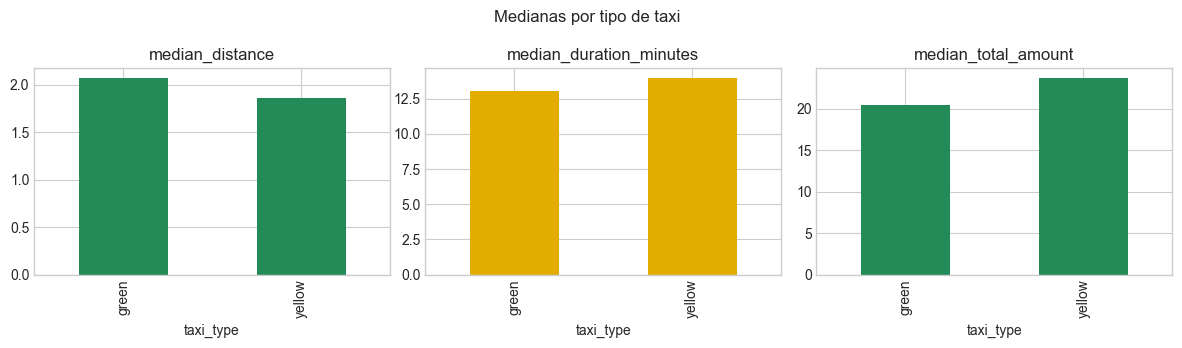

Green: viaje tipico de 2.07 millas, 13.08 minutos y $20.50.
Yellow: viaje tipico de 1.86 millas, 13.95 minutos y $23.69.


In [4]:
characteristics = run_sql(3)
display(characteristics)

comparison = characteristics.set_index('taxi_type')[['median_distance', 'median_duration_minutes', 'median_total_amount']]
comparison.plot(kind='bar', subplots=True, layout=(1, 3), figsize=(12, 3.5), legend=False, color=['#238b57', '#e3ad00'])
plt.suptitle('Medianas por tipo de taxi')
plt.tight_layout()
plt.show()

for row in characteristics.itertuples():
    print(
        f'{row.taxi_type.title()}: viaje tipico de {row.median_distance:.2f} millas, '
        f'{row.median_duration_minutes:.2f} minutos y ${row.median_total_amount:.2f}.'
    )

### 4. Medios de pago

**Consulta:** `sql/ejercicio_4_4.sql`  
**Objetivo:** medir la participacion de cada codigo de pago por tipo de taxi.  
**Decision:** conservar el codigo original junto a su etiqueta y agrupar codigos no reconocidos como `Missing/other`.

,taxi_type,payment_type,payment_method,trips,pct_trips
0,green,1,Credit card,268607,79.93
1,green,2,Cash,65870,19.60
2,green,3,No charge,1124,0.33
3,green,4,Dispute,471,0.14
4,yellow,1,Credit card,18937486,64.10
5,yellow,0,Flex Fare,7716590,26.12
6,yellow,2,Cash,2668379,9.03
7,yellow,4,Dispute,138632,0.47
8,yellow,3,No charge,80407,0.27
9,yellow,5,Unknown,2,0.00


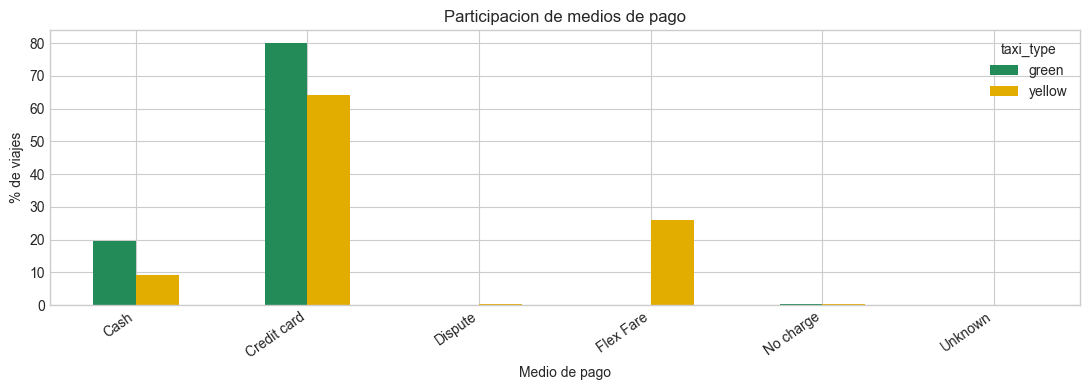

Green: predomina Credit card (79.93%).
Yellow: predomina Credit card (64.10%).


In [5]:
payments = run_sql(4)
display(payments)

payment_plot = payments.pivot(index='payment_method', columns='taxi_type', values='pct_trips').fillna(0)
ax = payment_plot.plot(kind='bar', figsize=(11, 4), color={'yellow': '#e3ad00', 'green': '#238b57'})
ax.set(title='Participacion de medios de pago', xlabel='Medio de pago', ylabel='% de viajes')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

for taxi, group in payments.groupby('taxi_type'):
    dominant = group.loc[group['trips'].idxmax()]
    print(f'{taxi.title()}: predomina {dominant.payment_method} ({dominant.pct_trips:.2f}%).')

### 5. Propinas en pagos con tarjeta

**Consulta:** `sql/ejercicio_4_5.sql`  
**Objetivo:** comparar frecuencia y magnitud de propinas cuando `payment_type = 1`.  
**Decision:** restringir el analisis a tarjeta porque las propinas en efectivo normalmente no quedan registradas en el taximetro.

,taxi_type,card_trips,card_trips_with_tip,pct_card_trips_with_tip,avg_tip,median_tip,avg_tip_pct_of_fare
0,green,268607,206712,76.96,3.29,2.75,21.90
1,yellow,18937486,17251422,91.10,4.28,3.29,25.44


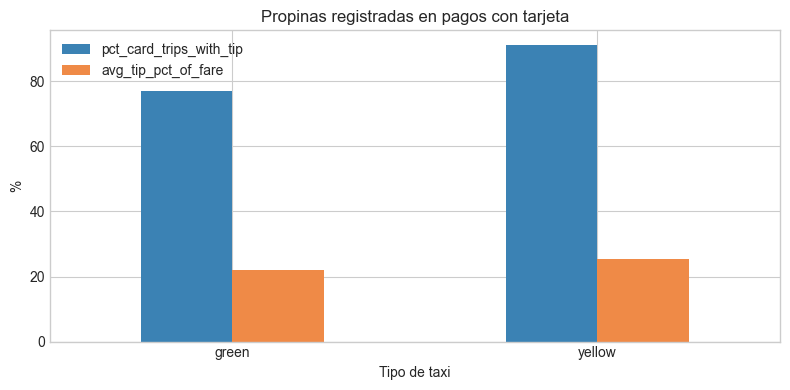

Green: 76.96% de pagos con tarjeta incluyo propina; propina mediana $2.75.
Yellow: 91.10% de pagos con tarjeta incluyo propina; propina mediana $3.29.


In [6]:
tips = run_sql(5)
display(tips)

ax = tips.set_index('taxi_type')[['pct_card_trips_with_tip', 'avg_tip_pct_of_fare']].plot(
    kind='bar', figsize=(8, 4), color=['#3b82b4', '#ef8a47']
)
ax.set(title='Propinas registradas en pagos con tarjeta', xlabel='Tipo de taxi', ylabel='%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

for row in tips.itertuples():
    print(
        f'{row.taxi_type.title()}: {row.pct_card_trips_with_tip:.2f}% de pagos con tarjeta '
        f'incluyo propina; propina mediana ${row.median_tip:.2f}.'
    )

### 6. Distribucion de distancias

**Consulta:** `sql/ejercicio_4_6.sql`  
**Objetivo:** observar la forma de la distribucion sin transferir millones de registros a pandas.  
**Decision:** usar intervalos interpretables y mantener una categoria separada para distancias no positivas.

,taxi_type,distance_range,trips,pct_trips
0,green,0. Non-positive,11741,3.49
1,green,"1. (0, 1]",46425,13.81
2,green,"2. (1, 3]",169110,50.32
3,green,"3. (3, 5]",49680,14.78
4,green,"4. (5, 10]",40313,12.00
5,green,"5. (10, 25]",18061,5.37
6,green,6. More than 25,742,0.22
7,yellow,0. Non-positive,936618,3.17
8,yellow,"1. (0, 1]",6303013,21.34
9,yellow,"2. (1, 3]",12966579,43.89


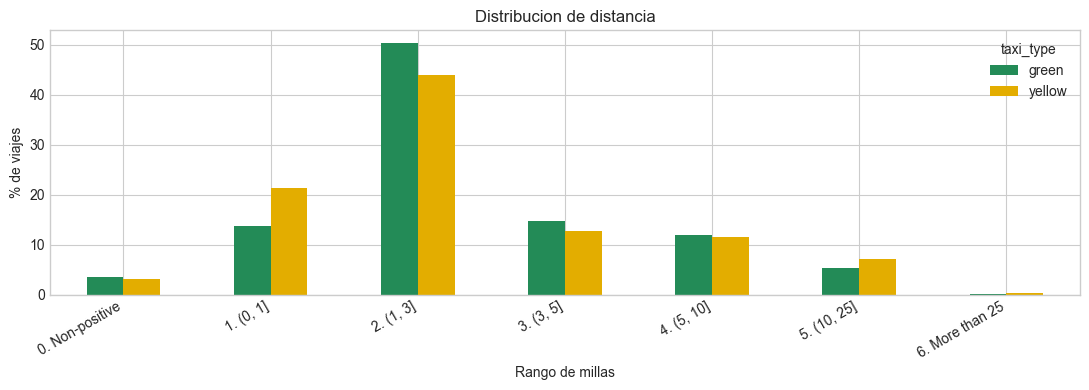

Green: el rango dominante fue 2. (1, 3] millas (50.32%).
Yellow: el rango dominante fue 2. (1, 3] millas (43.89%).


In [7]:
distance_distribution = run_sql(6)
display(distance_distribution)

distance_plot = distance_distribution.pivot(index='distance_range', columns='taxi_type', values='pct_trips').fillna(0)
ax = distance_plot.plot(kind='bar', figsize=(11, 4), color={'yellow': '#e3ad00', 'green': '#238b57'})
ax.set(title='Distribucion de distancia', xlabel='Rango de millas', ylabel='% de viajes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

for taxi, group in distance_distribution.groupby('taxi_type'):
    dominant = group.loc[group['trips'].idxmax()]
    print(f'{taxi.title()}: el rango dominante fue {dominant.distance_range} millas ({dominant.pct_trips:.2f}%).')

### 7. Valores atipicos e inconsistencias

**Consulta:** `sql/ejercicio_4_7.sql`  
**Objetivo:** contar reglas de alerta relacionadas con distancia, duracion, monto y velocidad implausible.  
**Decision:** las reglas son banderas exploratorias, no filtros definitivos. Se identifican tambien fechas fuera de 2026, que se excluyen de las metricas sustantivas. Una fila puede activar mas de una regla y debe investigarse antes de eliminarse.

,taxi_type,trips,pickup_outside_2026,non_positive_distance,distance_over_100_miles,zero_duration,duration_over_4_hours,total_over_500,speed_over_100_mph,pct_with_quality_flag
0,green,336086,14,11745,72,228,1219,21,1021,4.1611
1,yellow,29541512,16,936618,1196,371666,8505,791,6461,4.4424


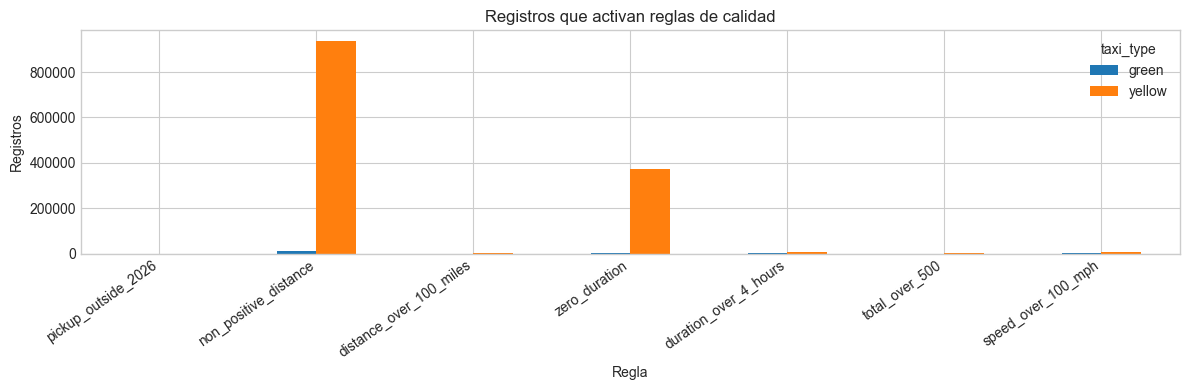

Green: 4.1611% tiene al menos una bandera de calidad.
Yellow: 4.4424% tiene al menos una bandera de calidad.


In [8]:
quality = run_sql(7)
display(quality)

quality_columns = [
    'pickup_outside_2026', 'non_positive_distance', 'distance_over_100_miles', 'zero_duration',
    'duration_over_4_hours', 'total_over_500', 'speed_over_100_mph'
]
ax = quality.set_index('taxi_type')[quality_columns].T.plot(kind='bar', figsize=(12, 4))
ax.set(title='Registros que activan reglas de calidad', xlabel='Regla', ylabel='Registros')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

for row in quality.itertuples():
    print(f'{row.taxi_type.title()}: {row.pct_with_quality_flag:.4f}% tiene al menos una bandera de calidad.')

### 8. Concentracion por zona de recogida

**Consulta:** `sql/ejercicio_4_8.sql`  
**Objetivo:** identificar las diez zonas con mayor cantidad de recogidas para cada servicio.  
**Decision:** reportar `PULocationID`; para mostrar nombres de zonas se requeriria incorporar el catalogo oficial de zonas TLC como una fuente documentada adicional.

,taxi_type,position,PULocationID,trips,pct_trips
0,green,1,74,88275,26.27
1,green,2,75,43037,12.81
2,green,3,95,16141,4.80
3,green,4,43,13277,3.95
4,green,5,166,12682,3.77
5,green,6,82,11786,3.51
6,green,7,41,11367,3.38
7,green,8,65,10722,3.19
8,green,9,130,9559,2.84
9,green,10,97,8920,2.65


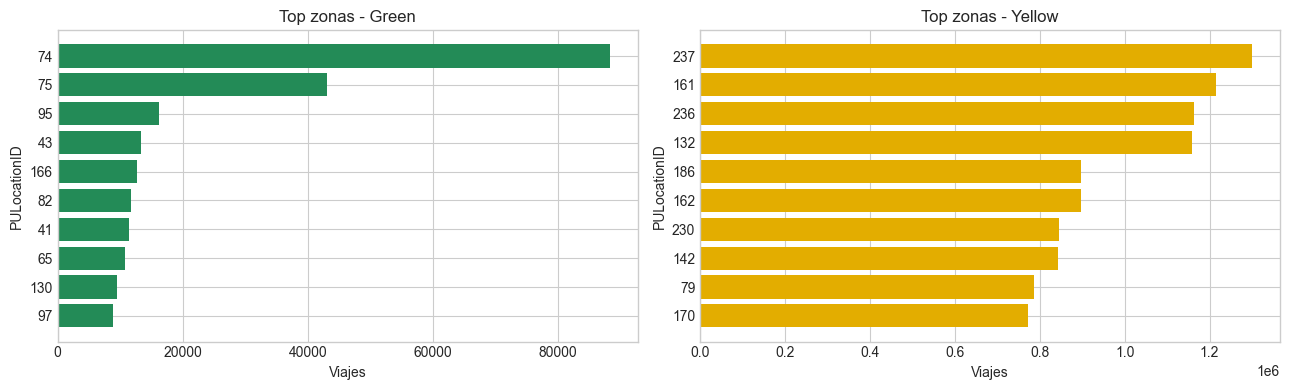

Green: la zona principal fue PULocationID 74 (26.27% de viajes).
Yellow: la zona principal fue PULocationID 237 (4.40% de viajes).


In [9]:
zones = run_sql(8)
display(zones)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (taxi, group) in zip(axes, zones.groupby('taxi_type')):
    group = group.sort_values('trips')
    ax.barh(group['PULocationID'].astype(str), group['trips'], color='#e3ad00' if taxi == 'yellow' else '#238b57')
    ax.set(title=f'Top zonas - {taxi.title()}', xlabel='Viajes', ylabel='PULocationID')
plt.tight_layout()
plt.show()

for taxi, group in zones.groupby('taxi_type'):
    top = group.loc[group['position'].idxmin()]
    print(f'{taxi.title()}: la zona principal fue PULocationID {int(top.PULocationID)} ({top.pct_trips:.2f}% de viajes).')

## 4.3 Hallazgos principales

La siguiente celda genera hallazgos cuantitativos a partir de los resultados obtenidos. Esto evita dejar conclusiones desactualizadas cuando la TLC publique meses adicionales de 2026.

In [10]:
trip_totals = characteristics.set_index('taxi_type')['trips']
volume_ratio = trip_totals['yellow'] / trip_totals['green']
peak_hours = hourly.loc[hourly.groupby('taxi_type')['trips'].idxmax()].set_index('taxi_type')
typical = characteristics.set_index('taxi_type')
dominant_payments = payments.loc[payments.groupby('taxi_type')['trips'].idxmax()].set_index('taxi_type')
quality_index = quality.set_index('taxi_type')
dominant_distance = distance_distribution.loc[
    distance_distribution.groupby('taxi_type')['trips'].idxmax()
].set_index('taxi_type')
top_zones = zones.loc[zones.groupby('taxi_type')['position'].idxmin()].set_index('taxi_type')

print(f'1. Yellow registro {volume_ratio:.1f} veces la cantidad de viajes de Green en los archivos disponibles.')
print(
    f"2. Las horas pico fueron {int(peak_hours.loc['yellow', 'pickup_hour']):02d}:00 para Yellow "
    f"y {int(peak_hours.loc['green', 'pickup_hour']):02d}:00 para Green."
)
print(
    f"3. La distancia mediana fue {typical.loc['yellow', 'median_distance']:.2f} millas en Yellow "
    f"y {typical.loc['green', 'median_distance']:.2f} millas en Green."
)
print(
    f"4. El pago dominante fue {dominant_payments.loc['yellow', 'payment_method']} en Yellow "
    f"({dominant_payments.loc['yellow', 'pct_trips']:.2f}%) y "
    f"{dominant_payments.loc['green', 'payment_method']} en Green "
    f"({dominant_payments.loc['green', 'pct_trips']:.2f}%)."
)
print(
    f"5. Las banderas de calidad afectan {quality_index.loc['yellow', 'pct_with_quality_flag']:.4f}% "
    f"de Yellow y {quality_index.loc['green', 'pct_with_quality_flag']:.4f}% de Green; "
    'por ello los extremos no deben eliminarse sin investigacion adicional.'
)
print(
    f"6. El rango de distancia mas comun fue {dominant_distance.loc['yellow', 'distance_range']} millas "
    f"en Yellow ({dominant_distance.loc['yellow', 'pct_trips']:.2f}%) y "
    f"{dominant_distance.loc['green', 'distance_range']} millas en Green "
    f"({dominant_distance.loc['green', 'pct_trips']:.2f}%)."
)
print(
    f"7. Green presenta mayor concentracion espacial: su zona lider, "
    f"PULocationID {int(top_zones.loc['green', 'PULocationID'])}, representa "
    f"{top_zones.loc['green', 'pct_trips']:.2f}% de viajes, frente a "
    f"{top_zones.loc['yellow', 'pct_trips']:.2f}% de la zona lider de Yellow."
)
print(
    f"8. Se detectaron {int(quality_index['pickup_outside_2026'].sum())} viajes con fecha de recogida "
    'fuera de 2026; se conservaron como evidencia de calidad, pero se excluyeron del resto del analisis.'
)

1. Yellow registro 87.9 veces la cantidad de viajes de Green en los archivos disponibles.
2. Las horas pico fueron 18:00 para Yellow y 17:00 para Green.
3. La distancia mediana fue 1.86 millas en Yellow y 2.07 millas en Green.
4. El pago dominante fue Credit card en Yellow (64.10%) y Credit card en Green (79.93%).
5. Las banderas de calidad afectan 4.4424% de Yellow y 4.1611% de Green; por ello los extremos no deben eliminarse sin investigacion adicional.
6. El rango de distancia mas comun fue 2. (1, 3] millas en Yellow (43.89%) y 2. (1, 3] millas en Green (50.32%).
7. Green presenta mayor concentracion espacial: su zona lider, PULocationID 74, representa 26.27% de viajes, frente a 4.40% de la zona lider de Yellow.
8. Se detectaron 30 viajes con fecha de recogida fuera de 2026; se conservaron como evidencia de calidad, pero se excluyeron del resto del analisis.


## 4.4 Conclusion

El analisis compara ambos servicios sin asumir que tienen la misma escala y usa medianas o porcentajes cuando los promedios o conteos absolutos pueden resultar engañosos. Las banderas de calidad muestran que la limpieza inicial no reemplaza la validacion analitica: distancias, duraciones, montos y velocidades extremas deben revisarse segun el objetivo antes de construir indicadores definitivos. Los resultados representan exclusivamente los meses de 2026 disponibles al momento de ejecutar el flujo.